
# Parte 1: Álgebra Linear - Vetores

### 1. Contextualização histórica e motivação

A presente seção estabelece o conceito fundamental de representação espacial e armazenamento de atributos em computação, essencial para o mapeamento de entidades complexas.

Historicamente, o conceito de vetor surgiu das tentativas de matemáticos como Descartes e Grassmann de representar geometricamente forças e coordenadas no espaço. Antes da modelagem vetorial, dados multidimensionais eram tratados como variáveis escalares isoladas, o que tornava o cálculo de interações em sistemas complexos matematicamente exaustivo e de difícil abstração. A solução baseada em vetores permitiu agrupar múltiplas características em uma única estrutura unificada. No estado atual da Inteligência Artificial em 2024-2025, os vetores formam a unidade atômica de dados que trafega nas redes neurais; qualquer entrada de texto, imagem ou som é inevitavelmente convertida em um vetor unidimensional (ou tensor) antes do processamento nos espaços latentes de _embeddings_. Um exemplo tangível e prático é o Google Maps, que utiliza coordenadas vetoriais bidimensionais de latitude e longitude para traçar rotas e posições relativas na Terra.

### 2. Intuição e visualização

A seção a seguir traduz a formulação matemática de um vetor unidimensional em uma estrutura de setas direcionadas e localizações no plano, facilitando a percepção visual da geometria espacial.

Um vetor pode ser interpretado como um ponto específico localizado em um espaço multidimensional, ou equivalentemente, como uma seta que parte da origem geométrica (0, 0) e avança em direção a este ponto. A seta intrinsecamente carrega duas propriedades absolutas: a magnitude, que dita o seu comprimento espacial, e a direção, que estabelece a sua orientação angular em relação aos eixos ortogonais. A soma de dois vetores reflete a combinação de seus deslocamentos sequenciais, conectando a base de um vetor à ponta do outro.



In [10]:
%pip install numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


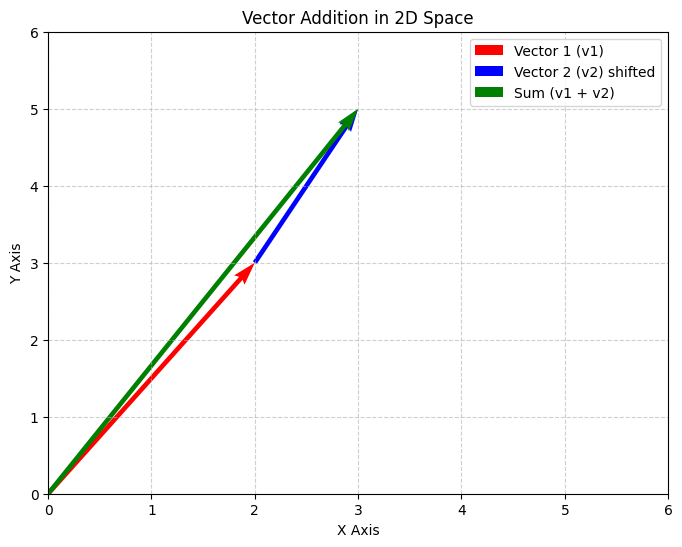

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Definindo vetores
origin = np.array([0, 0])
v1 = np.array([2, 3])
v2 = np.array([1, 2])
v_sum = v1 + v2

# Criando a figura
plt.figure(figsize=(8, 6))
plt.quiver(*origin, v1[0], v1[1], color='r', angles='xy', scale_units='xy', scale=1, label='Vector 1 (v1)')
plt.quiver(v1[0], v1[1], v2[0], v2[1], color='b', angles='xy', scale_units='xy', scale=1, label='Vector 2 (v2) shifted')
plt.quiver(*origin, v_sum[0], v_sum[1], color='g', angles='xy', scale_units='xy', scale=1, label='Sum (v1 + v2)')

plt.xlim(0, 6)
plt.ylim(0, 6)
plt.grid(True, linestyle='--', alpha=0.6)
plt.title('Vector Addition in 2D Space')
plt.xlabel('X Axis')
plt.ylabel('Y Axis')
plt.legend()
plt.show()




### 3. Teoria formal

A seção atual expõe o rigor aritmético das operações sobre estruturas de dimensão única, solidificando as manipulações fundamentais da álgebra vetorial.

Um vetor $\mathbf{v}$ de dimensão $n$ pertence ao espaço $\mathbb{R}^n$ e é representado formalmente por uma tupla ordenada de componentes: $\mathbf{v} = [v_1, v_2, \dots, v_n]$. A soma vetorial requer impreterivelmente que ambos os vetores compartilhem a mesma dimensionalidade. Para dois vetores $\mathbf{x}, \mathbf{y} \in \mathbb{R}^n$, a operação escalar de adição é definida componente a componente: $$\mathbf{x} + \mathbf{y} = [x_1 + y_1, x_2 + y_2, \dots, x_n + y_n]$$ A limitação explícita desta formulação reside na incompatibilidade arquitetural entre vetores de tamanhos díspares. A operação entre um vetor tridimensional e um quadridimensional é matematicamente inexistente, falhando durante o cômputo. A magnitude do vetor (Norma L2) é definida rigorosamente por $||\mathbf{v}|| = \sqrt{\sum_{i=1}^{n} v_i^2}$.

### 4. Algoritmos

Este segmento decompõe o algoritmo genérico de processamento iterativo, o que revela o processamento em baixo nível exigido para somar componentes de estruturas matemáticas isoladas.



ALGORITMO SomaVetorialEscalar
ENTRADA: Vetor V1 de tamanho N, Vetor V2 de tamanho N
SAÍDA: Vetor V_RESULT de tamanho N

Se tamanho(V1) for diferente de tamanho(V2) então:
    Retornar Erro "Dimensões incompatíveis"

Para i de 0 até N-1 faça:
    V_RESULT[i] = V1[i] + V2[i]

Retornar V_RESULT




O pseudocódigo itera explicitamente sobre cada índice válido. Ele extrai os escalares guardados nas posições idênticas de ambas as estruturas, computa a operação aritmética simples e injeta o valor na coordenada idêntica do vetor de saída. O mecanismo impõe um passo inicial obrigatório de validação dimensional para prevenir acessos a espaços de memória inexistentes.

### 5. Implementação from scratch

O código a seguir traduz a teoria vetorial em Python interpretado e valida a exatidão lógica contra a estrutura otimizada provida pela biblioteca NumPy.



In [12]:
import numpy as np

def vector_addition(v1: list, v2: list) -> list:
    """
    Computes the element-wise addition of two vectors using pure Python.

    Args:
        v1 (list): The first vector represented as a list of numbers.
        v2 (list): The second vector represented as a list of numbers.

    Returns:
        list: A new vector containing the sum of the components.
    """
    # Validação de hipótese dimensional
    if len(v1) != len(v2):
        raise ValueError("Vectors must possess the same dimension.")

    # Computação iterativa via list comprehension
    return [v1[i] + v2[i] for i in range(len(v1))]

# Definição e execução
v_a = [1.0, 2.0, 3.0]
v_b = [4.0, -1.0, 5.0]

result_scratch = vector_addition(v_a, v_b)
result_numpy = np.add(np.array(v_a), np.array(v_b)).tolist()

print(f"Scratch Result: {result_scratch}")
print(f"NumPy Result:   {result_numpy}")
assert result_scratch == result_numpy, "Mismatch in vector addition calculations."


Scratch Result: [5.0, 1.0, 8.0]
NumPy Result:   [5.0, 1.0, 8.0]




### 6. Implementação em PyTorch

A presente etapa refaz o experimento valendo-se dos tensores da biblioteca PyTorch, o que ilustra o padrão moderno de alocação de estruturas algébricas na área de aprendizado profundo.



In [13]:
import torch

# Instanciação estrita de tensores flutuantes unidimensionais
tensor_a = torch.tensor([1.0, 2.0, 3.0], dtype=torch.float32)
tensor_b = torch.tensor([4.0, -1.0, 5.0], dtype=torch.float32)

# A API do PyTorch sobrecarrega o operador aritmético básico (+)
# invocando a função nativa torch.add() através da sua engine em C++
tensor_sum = tensor_a + tensor_b

print(f"PyTorch Tensor Addition: {tensor_sum.tolist()}")
assert tensor_sum.tolist() == result_scratch, "Discrepancy with reference implementation."


PyTorch Tensor Addition: [5.0, 1.0, 8.0]




Observe que a API do framework preserva a semântica nativa do Python, porém submete o cálculo para estruturas otimizadas passíveis de migração para memória gráfica (GPU).

### 7. Experimentos e análise

Esta seção injeta escalares de variados graus sobre um dado vetor, o que torna visível a alteração espacial que este tipo de multiplicação desencadeia na magnitude de entidades geométricas.



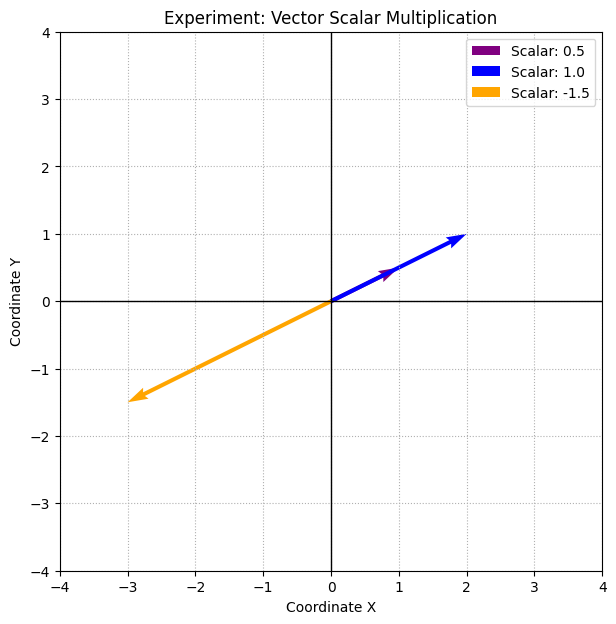

In [14]:
import numpy as np
import matplotlib.pyplot as plt

origin = np.array([0, 0])
v_base = np.array([2.0, 1.0])
scalars = [0.5, 1.0, -1.5]

plt.figure(figsize=(7, 7))
colors = ['purple', 'blue', 'orange']

for scalar, color in zip(scalars, colors):
    v_scaled = v_base * scalar
    plt.quiver(*origin, v_scaled[0], v_scaled[1], color=color, angles='xy',
               scale_units='xy', scale=1, label=f'Scalar: {scalar}')

plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)
plt.grid(True, linestyle=':')
plt.title('Experiment: Vector Scalar Multiplication')
plt.xlabel('Coordinate X')
plt.ylabel('Coordinate Y')
plt.legend()
plt.show()




Ao analisar a plotagem, nota-se que modificações escalares preservam rigorosamente a colinearidade do vetor; a multiplicação altera primariamente o alongamento (magnitude) e reverte a direção intrínseca somente quando o fator aritmético mergulha no espectro negativo. Erros empíricos nesta etapa emergem caso variáveis vetoriais puras sejam misturadas sem o broadcasting apropriado nos arrays numéricos.

### 8. Exercícios

Os exercícios compilam simulações diretas para verificação de conceitos lógicos recém-adquiridos.

**Resolvidos:**

1. A representação espacial no Google Maps baseia-se em conceitos vetoriais bidimensionais. Identifique a estrutura vetorial utilizada e se suas propriedades mudam dependendo da direção. _Solução:_ A estrutura mapeia Latitude e Longitude. A representação posicional muda totalmente dependendo da direção (sinal) dos escalares, visto que um avanço negativo inverte a trajetória ao longo do eixo cardinal do planeta.
2. Dado $\mathbf{v} =$, qual é o tamanho estrutural deste vetor? _Solução:_ Seu tamanho formal é 3 dimensões (shape = (3,)).
3. Calcule analiticamente o vetor resultante de $\mathbf{v_1} =$ e $\mathbf{v_2} =$ através da subtração $\mathbf{v_1} - \mathbf{v_2}$. _Solução:_ Elemento por elemento: $ = [-1, -75, -1]$.

**Desafios Abertos:**

1. Implemente uma função customizada em Python puro que não apenas verifique a equivalência dimensional, mas suporte operações vetoriais sobre listas encadeadas contendo um bilhão de posições lidando com estouro de memória ram (Out-of-Memory). Dica: Pense no conceito lógico do `yield` e dos iteradores (generators).
2. Uma matriz pode ser vista como um vetor de vetores. Construa a lógica para generalizar sua função puramente unidimensional de `vector_addition` para somar listas bidimensionais recursivamente.

---

# Parte 2: Álgebra Linear - Matrizes

### 1. Contextualização histórica e motivação

A presente seção descreve a justificativa fundamental que elevou as matrizes ao posto de principal mecanismo para processamento em larga escala na inteligência computacional.

O formalismo matricial ganhou propulsão na matemática durante o século XIX pelas mãos de James Joseph Sylvester e Arthur Cayley. A notação consolidou equações lineares intrincadas em blocos retangulares concisos, o que solucionava o esgotamento humano de escrever laços longos para incógnitas interdependentes. A motivação de usar matrizes em 2024-2025 foca-se exclusivamente na velocidade via paralelização massiva: os sistemas deep learning processam conjuntos agrupados de vetores (Batch Predictions) injetados em Unidades de Processamento Gráfico (GPUs) criadas nativamente para triturar equações lineares compostas por matrizes em ciclos de clock mínimos. Sem a representação matricial tabular, modelagens imensas demandariam laços seriais iterativos por amostra, tornando inviável o treino do backpropagation na época e a consolidação contemporânea de arquiteturas massivas baseadas na atenção.

### 2. Intuição e visualização

A seção a seguir converte o array bidimensional de números num construto tátil, materializando os efeitos espaciais que o produto vetorial-matricial introduz aos dados.

Uma matriz consiste em um conjunto retangular empilhado de múltiplos vetores, definido e moldado rigidamente por sua contagem de linhas e de colunas. A intuição da multiplicação atua como uma transformação ou rotação das coordenadas de um espaço projetadas em um novo espaço.



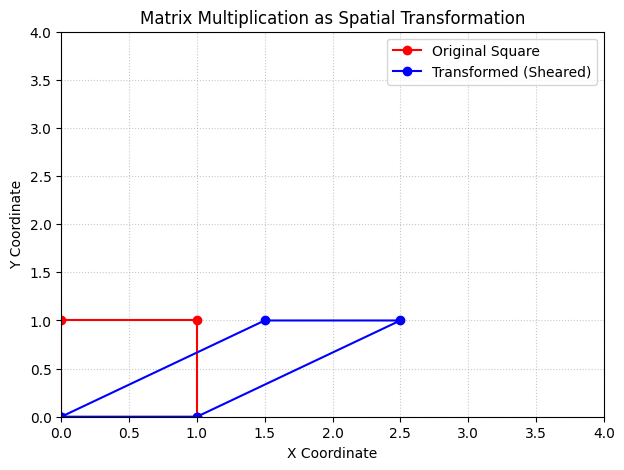

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Pontos originais formando um quadrado unitário (fechado)
points = np.array([
    [0, 0],
    [1, 0],
    [1, 1],
    [0, 1],
    [0, 0],  # fecha o quadrado
])

# Matriz de transformação (Cisalhamento / Shear)
shear_matrix = np.array([
    [1, 1.5],
    [0, 1  ],
])

# Multiplicação Matricial para transformação geométrica
transformed_points = points @ shear_matrix.T

plt.figure(figsize=(7, 5))
plt.plot(points[:, 0], points[:, 1], 'ro-', label='Original Square')
plt.plot(transformed_points[:, 0], transformed_points[:, 1], 'bo-', label='Transformed (Sheared)')

plt.xlim(0, 4)
plt.ylim(0, 4)
plt.grid(True, linestyle=':', alpha=0.7)
plt.title('Matrix Multiplication as Spatial Transformation')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.legend()
plt.show()




### 3. Teoria formal

A seção elucida os teoremas axiomáticos e as restrições que regem o alinhamento entre duas entidades matriciais durante um cálculo relacional.

Uma matriz $\mathbf{A} \in \mathbb{R}^{N \times M}$ é uma tabela com $N$ linhas e $M$ colunas. O produto matricial matricial $\mathbf{C} = \mathbf{A} \cdot \mathbf{B}$ exige incondicionalmente uma conformidade dimensional estrita: o número de colunas ($M$) do operando $\mathbf{A}$ deve igualar perfeitamente o número de linhas da matriz $\mathbf{B}$ (de dimensão $M \times P$). Se esta hipótese se comprovar verdadeira, o tensor resultante assume os vértices externos herdados $\mathbf{C} \in \mathbb{R}^{N \times P}$. A fórmula algébrica subjacente é o produto interno entre a linha $i$ e a coluna $j$: $$C_{ij} = \sum_{k=1}^{M} A_{ik} B_{kj}$$ A matriz identidade $\mathbf{I}$, caracterizada por reter zeros absolutos contendo apenas o número um em sua diagonal primária, atua como operador neutro tal que $\mathbf{A} \cdot \mathbf{I} = \mathbf{A}$.

### 4. Algoritmos

O presente trecho ilustra a complexidade cúbica do processador durante as validações matriciais puras sem alavancar otimizações de memória.



ALGORITMO MultiplicacaoMatricialClassica
ENTRADA: Matriz A [N x M], Matriz B [M x P]
SAÍDA: Matriz C [N x P]

Se M não for igual ao número de linhas de B, disparar exceção.

Inicializar C como matriz vazia de zeros com dimensão N x P.

Para linha i de 0 até N-1 faça:
    Para coluna j de 0 até P-1 faça:
        SomaAcumulada = 0
        Para índice k de 0 até M-1 faça:
            SomaAcumulada += A[i][k] * B[k][j]
        C[i][j] = SomaAcumulada

Retornar C



O algoritmo emprega inevitavelmente três estruturas de repetição aninhadas ($N \times P \times M$), acarretando em complexidade computacional na base de $O(N^3)$ em conjuntos perfeitamente quadrados. Ele agrupa a soma de fatores sequenciais ao escorregar horizontalmente na linha matriz inicial e verticalmente nas casinhas da matriz secundária.

### 5. Implementação from scratch

Este bloco codifica os laços condicionais de verificação formal usando literais embutidos na linguagem para destacar a latência dos processos aninhados triplos da matemática pura.



In [16]:
import numpy as np

def manual_matrix_multiplication(A: list, B: list) -> list:
    """
    Computes standard matrix multiplication O(N^3) utilizing pure Python loops.

    Args:
        A (list of lists): Left matrix.
        B (list of lists): Right matrix.

    Returns:
        list of lists: The resulting product matrix.
    """
    rows_A = len(A)
    cols_A = len(A[0])
    rows_B = len(B)
    cols_B = len(B[0])

    if cols_A != rows_B:
        raise ValueError(f"Dim mismatch: {cols_A} cols vs {rows_B} rows.")

    # Inicializa o arranjo vazio [rows_A x cols_B]
    C = [[0.0 for _ in range(cols_B)] for _ in range(rows_A)]

    for i in range(rows_A):
        for j in range(cols_B):
            for k in range(cols_A):
                C[i][j] += A[i][k] * B[k][j]

    return C

# Experimento Base
matrix_a = [[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]]       # 2x3
matrix_b = [[7.0, 8.0], [9.0, 10.0], [11.0, 12.0]]   # 3x2

res_scratch = manual_matrix_multiplication(matrix_a, matrix_b)
res_numpy = np.matmul(np.array(matrix_a), np.array(matrix_b)).tolist()

print("Scratch Output:", res_scratch)
print("NumPy Output:  ", res_numpy)
assert res_scratch == res_numpy, "Matrix logic verification failed."


Scratch Output: [[58.0, 64.0], [139.0, 154.0]]
NumPy Output:   [[58.0, 64.0], [139.0, 154.0]]




### 6. Implementação em PyTorch

A seção subsequente transpõe o mesmo processamento ao motor atômico do PyTorch, invocando o seu backend unificado desenvolvido em arquiteturas primitivas de paralelismo.



In [17]:
import torch

t_matrix_a = torch.tensor([[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]])
t_matrix_b = torch.tensor([[7.0, 8.0], [9.0, 10.0], [11.0, 12.0]])

# PyTorch opera com a função nativa matmul, ou o sugar syntax @
# Essa instrução submete cálculos para threads de GPU se disponíveis
t_result = torch.matmul(t_matrix_a, t_matrix_b)

print("PyTorch Output:\n", t_result)
# Valida conformidade com resultado esperado
expected = torch.tensor([[58.0, 64.0], [139.0, 154.0]])
assert torch.allclose(t_result, expected), "Framework calculation drift."


PyTorch Output:
 tensor([[ 58.,  64.],
        [139., 154.]])




O método `torch.matmul` internaliza a abstração da paralelização. O motor mapeia blocos inteiros em registradores isolados (tiling), erradicando a letargia proveniente da recursão tradicional apresentada no pseudo-código.

### 7. Experimentos e análise

O tópico mensura e plota o abismo abismal de desempenho entre metodologias assíncronas serializadas na linguagem, contra a alavancagem de APIs vetorizadas otimizadas para tensores matemáticos.



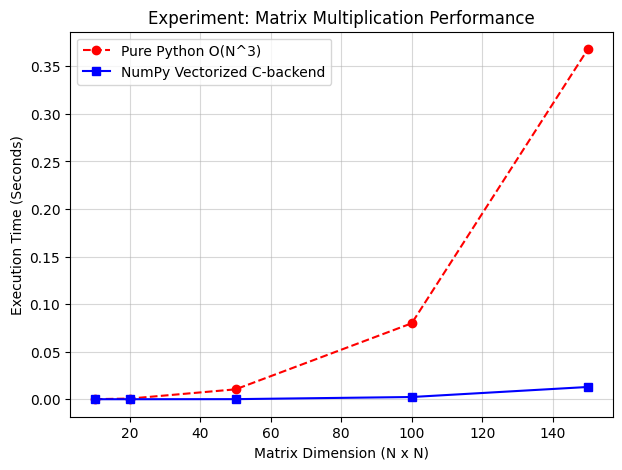

In [18]:
import time
import matplotlib.pyplot as plt
import numpy as np

sizes = [10, 20, 50, 100, 150]
time_scratch = []
time_numpy = []

for s in sizes:
    A_exp = np.random.rand(s, s).tolist()
    B_exp = np.random.rand(s, s).tolist()

    A_np = np.array(A_exp)
    B_np = np.array(B_exp)

    # Avaliação Manual
    t0 = time.time()
    _ = manual_matrix_multiplication(A_exp, B_exp)
    time_scratch.append(time.time() - t0)

    # Avaliação NumPy (Baseado em bibliotecas BLAS em C)
    t0 = time.time()
    _ = np.matmul(A_np, B_np)
    time_numpy.append(time.time() - t0)

plt.figure(figsize=(7, 5))
plt.plot(sizes, time_scratch, 'r--o', label='Pure Python O(N^3)')
plt.plot(sizes, time_numpy, 'b-s', label='NumPy Vectorized C-backend')
plt.title('Experiment: Matrix Multiplication Performance')
plt.xlabel('Matrix Dimension (N x N)')
plt.ylabel('Execution Time (Seconds)')
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()




Observe que a implementação manual soçobra exibindo a curvatura inconfundível de uma explosão cúbica. Na vida real dos engenheiros de modelo, a ineficiência do Python puro inviabilizaria qualquer treinamento neural. A utilização obrigatória do Numpy ou tensores de PyTorch estende um processamento amortizado, diagnosticando que não se trata do algoritmo lógico estar mal montado, mas de seu ambiente subjacente não estar utilizando processadores de registros nativos da placa mãe.

### 8. Exercícios

As avaliações consolidam o entendimento das restrições de compatibilidade geométrica entre duas matrizes.

**Resolvidos:**

1. Pode-se multiplicar uma matriz $A$ com tamanho $(2 \times 3)$ por uma matriz $B$ com tamanho $(3 \times 2)$? Qual a dimensão resultante? _Solução:_ É perfeitamente exequível. O valor interno é igual ($3 = 3$). A dimensão absorve os exteriores, resultando em matriz $(2 \times 2)$.
2. A matriz A contém a forma $(3 \times 3)$ e B possui $(2 \times 3)$. Elas podem ser comutadas linearmente pela multiplicação $A \cdot B$? _Solução:_ O número de colunas da matriz inicial (3) difere das linhas da segunda (2). Como não são simétricos, é matematicamente insustentável.
3. O que acontece com a memória do Python quando tenta-se executar o arranjo falho discutido na segunda questão por meio de operadores iterativos de soma e subtração diretos sem a multiplicação de vetores? _Solução:_ A engine tentará parear índices do último elemento num espaço de memória inexistente e disparará uma falha formal de "Index Out of Bounds" por ausência do quarto ou respectivo índice não instanciado.

**Desafios Abertos:**

1. Aborde o problema matemático matricial da "Matriz Transposta". Codifique e crie um método customizado invertendo lógicas do eixo horizontal perante o eixo vertical sem auxílio do PyTorch.
2. Analisando as regras do otimizador de Strassen, pesquise o mecanismo de divisão relacional que atenua o estrangulamento iterativo do tempo O(N^3) até atingir o platô reduzido. Descreva em pseudocódigo recursivo este passo a passo.

---

# Parte 3: Derivada

### 1. Contextualização histórica e motivação

A explanação que se segue introduz a origem do maquinário do cálculo diferencial e o motivo fundamental pelo qual todo o campo de aprendizado mecânico gravita obrigatoriamente em torno do seu funcionamento atômico.

O cálculo diferencial foi formulado independentemente por Isaac Newton e Gottfried Leibniz. Historicamente, ele viabilizou descrições minuciosas da mecânica dos corpos em movimento que careciam de avaliações de acelerações não estáticas. No terreno da Inteligência Artificial em 2024-2025, o treinamento de todo e qualquer neurônio profundo ampara-se no gradiente descendente. Um modelo computacional em nada enxerga senão números; a função não dita uma solução direta, mas o Gradiente sinaliza o erro numérico e indica qual o vetor escalar exato pelo qual as conexões da rede devem transitar a fim de rebaixar a penalidade para a menor variância instantânea e otimizar os pesos operacionais matematicamente pelas costas. Sem o uso de derivadas organizadas via o Algoritmo de _Backpropagation_ em 1986, as redes modernas meramente permaneceriam fixas e presas a inferências simplistas inaptas a generalizar dados multidimensionais espessos.

### 2. Intuição e visualização

A etapa atual traduz as métricas espaciais teóricas em representações tangíveis atreladas a conceitos contínuos de cinemática e declive rotacional.

A derivada afere estritamente a taxa de variação instantânea num limite contínuo e minúsculo. A intuição primordial mapeia o motor de um carro na autoestrada: quando a variação acelera em progressão, a derivada ostenta traços de crescimentos absolutos no gráfico. Quando retém a inércia estática (velocidade cruzeiro), a métrica congela o coeficiente linear cravando sua variação nula. Graficamente, ela personifica a inclinação da reta tangente exata de um pico minucioso que atinge superficialmente a parábola sem cortá-la grosseiramente.



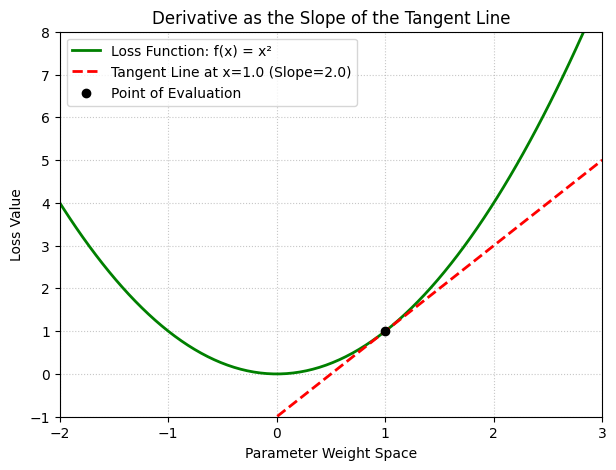

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Domínio da função Quadrática
x = np.linspace(-3, 3, 100)
f_x = x ** 2

# Ponto de observação fixado em X=1
x0 = 1.0
y0 = x0 ** 2

# Derivada analítica f'(x) = 2x
derivative = 2 * x0

# Equação estrita da Linha Tangente: y = m*(x-x0) + y0
tangent_line = derivative * (x - x0) + y0

plt.figure(figsize=(7, 5))
plt.plot(x, f_x, 'g-', linewidth=2, label='Loss Function: f(x) = x²')
plt.plot(x, tangent_line, 'r--', linewidth=2, label=f"Tangent Line at x={x0} (Slope={derivative})")
plt.scatter([x0], [y0], color='black', zorder=5, label='Point of Evaluation')

plt.xlim(-2, 3)
plt.ylim(-1, 8)
plt.title('Derivative as the Slope of the Tangent Line')
plt.xlabel('Parameter Weight Space')
plt.ylabel('Loss Value')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()




### 3. Teoria formal

Este segmento detalha as anotações do cálculo e regras estritas exigidas para desagrupar blocos complexos de funções compostas.

Para funções compostas de dimensão única, a anotação clássica reside em $f'(x)$ ou $\frac{df}{dx}$. A regra vital e inegociável da engenharia de redes neurais artificiais atende pela **Regra da Cadeia**. Dada uma função submersa na modelagem de uma segunda $f(g(x))$, o desdobramento se dá operando as fronteiras de fora para dentro: $$\frac{d}{dx}f(g(x)) = f'(g(x)) \cdot g'(x)$$ Em terrenos espessos povoados com múltiplas varáveis $f(x, y)$, invoca-se as Derivadas Parciais, operadas travando e cristalizando os demais itens em constantes nulas. O conjunto amalgamado destas derivadas atende pelo nome **Gradiente** ($\nabla f$), um vetor numérico imutável que aponta geometricamente para a rotação que a encosta sobe com maior rapidez perante o espaço curvo de avaliações algorítmicas do aprendizado.

### 4. Algoritmos

A porção de codificação genérica descreve uma engrenagem recursiva numérica capaz de aproximar aproximações estáticas tangentes perante pontos inatingíveis via avaliações delta.



ALGORITMO AproximacaoNumericaDaDerivada
ENTRADA: Funcao F, Ponto X, Precisao Delta
SAÍDA: Escalar representando a taxa de variação

# Aplicação da fronteira e definição formal dos limites numéricos de Newton
F_novo = Computar F(X + Delta)
F_atual = Computar F(X)

Variacao_Y = F_novo - F_atual
Derivada = Variacao_Y / Delta

Retornar Derivada



O processamento isola pequenos solavancos progressivos alimentados aos tensores. A métrica deduz numericamente um substituto satisfatório de declives onde a função analítica demonstra-se inoperante ou cega ao processo algorítmico, a custo da erosão de floats e decimais flutuantes.

### 5. Implementação from scratch

A sequência aplica as diretrizes lógicas do diferencial aproximado contrastando perfeitamente a avaliação matemática do comportamento parabólico isolado por limites diminutos de flutuação.



In [20]:
def f_quadratic(x: float) -> float:
    """Mathematical definition of a quadratic loss curve."""
    return x ** 2

def numerical_derivative(f: callable, x: float, delta: float = 1e-5) -> float:
    """
    Computes the numerical derivative approximation utilizing finite differences.

    Args:
        f (callable): Function to evaluate.
        x (float): Scalar evaluation point.
        delta (float): Limit infinitesimally close to zero.

    Returns:
        float: Computed derivative scalar.
    """
    # Aplicando limite da variação central formalmente
    return (f(x + delta) - f(x - delta)) / (2 * delta)

x_val = 3.0
analytical_res = 2 * x_val
numerical_res = numerical_derivative(f_quadratic, x_val)

print(f"Analytical Reference: {analytical_res}")
print(f"Numerical Scratch:    {numerical_res:.5f}")
# Tolerância de imprecisão de hardware é absorvida
assert abs(analytical_res - numerical_res) < 1e-4, "Numerical approximation drifted significantly."


Analytical Reference: 6.0
Numerical Scratch:    6.00000




### 6. Implementação em PyTorch

O presente extrato introduz o motor interno do Autograd e elucida o mapeamento dinâmico encarregado pela montagem silenciosa de retornos derivados das redes massivas contemporâneas.



In [21]:
import torch

# Tensor instanciado contendo monitoramento vitalício das operações computacionais do grafo
x_tensor = torch.tensor([3.0], requires_grad=True)

# Processo direto estrito (Forward Pass)
loss_fn = x_tensor ** 2

# Mecanismo do Algoritmo Backpropagation retrogredindo a cadeia funcional
loss_fn.backward()

# Visualização da acomodação do erro gradiente repassado internamente aos componentes atrelados
print(f"PyTorch Autograd Derivative: {x_tensor.grad.item()}")
assert x_tensor.grad.item() == 6.0, "Autograd Engine failed execution."


PyTorch Autograd Derivative: 6.0




O construto mágico do `.backward()` desvenda as dores do cientista modelando o cômputo sem a exigência letal de derivar na caneta equações hiper-paramétricas exaustivas com milhões e milhões de multiplicações em tensores contínuos.

### 7. Experimentos e análise

O teste atrela o coeficiente diferencial isolado ao multiplicador escalonar do passo do otimizador algorítmico global, rastreando desvios na descida em relação à margem aceitável adaptativa.



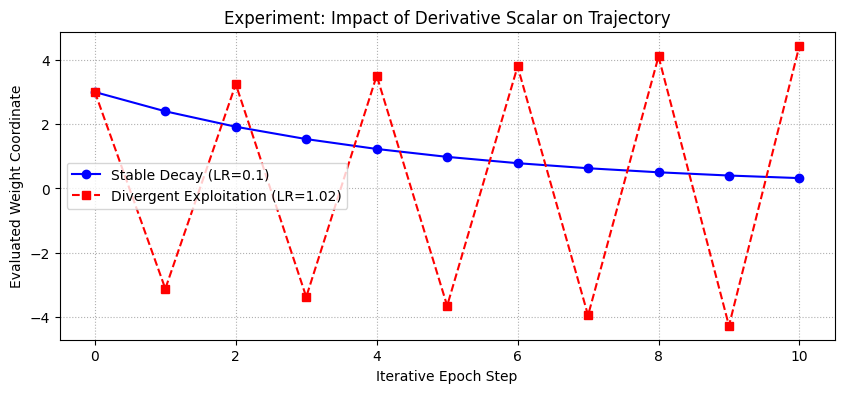

In [22]:
import numpy as np
import matplotlib.pyplot as plt

def grad_descent_simulation(start_x, lr, epochs=10):
    trajectory = [start_x]
    x_curr = start_x
    for _ in range(epochs):
        grad = 2 * x_curr # Derivada isolada
        x_curr = x_curr - lr * grad # Descida na reta diametralmente exposta
        trajectory.append(x_curr)
    return trajectory

# Avaliação perigosa do Over-Shooting e da lentidão por derivadas truncadas
traj_stable = grad_descent_simulation(start_x=3.0, lr=0.1)
traj_explode = grad_descent_simulation(start_x=3.0, lr=1.02) # Taxa agressiva multiplicada pela derivada

plt.figure(figsize=(10, 4))
plt.plot(traj_stable, 'b-o', label='Stable Decay (LR=0.1)')
plt.plot(traj_explode, 'r--s', label='Divergent Exploitation (LR=1.02)')
plt.title('Experiment: Impact of Derivative Scalar on Trajectory')
plt.xlabel('Iterative Epoch Step')
plt.ylabel('Evaluated Weight Coordinate')
plt.legend()
plt.grid(True, linestyle=':')
plt.show()




Verifica-se categoricamente na avaliação que ao empurrar um escalonador absurdo multiplicado pela derivada robusta no erro original, as passadas ignoram o mergulho na concavidade oscilando brutalmente nas montanhas laterais e explodindo na divergência numérica do aprendizado falho e ineficiente.

### 8. Exercícios

A ramificação do treinamento exige a formulação destas avaliações fundamentadas aos analistas.

**Resolvidos:**

1. Dado um carro operando com inércia constante de $100km/h$, qual é o cálculo aproximado referencial do módulo da derivada de seu modelo em variação temporal direta? _Solução:_ É imperativamente nula. Em velocidade e inércia fixas as avaliações instantâneas de mudança (Derivada) desabam pra marca algébrica nula.
2. Ao retro-propagar falhas, o Gradiente afere a taxa máxima de crescimento no declive da rede. Em contrapartida, de que forma o otimizador descobre o mergulho para varrer as instabilidades perante uma vala vazia? _Solução:_ A lógica engatilha uma multiplicação cruzada que converte o vetor por uma negativa diametral atrelada pelo peso multiplicador da aprendizagem forçando a navegação diametral oposta perante a elevação cravada no terreno da curva perniciosa.
3. Resolva a expressão $\frac{d}{dx}$ de $f(g(x)) = (3x + 2)^2$ empregando exclusivamente a regrinha analítica de Cadeias Funcionais ensinada no embasamento algébrico da teoria. _Solução:_ Projeta a carcaça externa absorvendo o 2 caindo para baixo: $2 \cdot (3x + 2)^1$. E recobra a avaliação no miolo interior gerando estritamente: $3$. Produto em união de ambas as equações soltas consolida o resultado atômico em $6 \cdot (3x + 2)$.

**Desafios Abertos:**

1. Substitua e aplique a variação de cálculo em Python com limite de fronteiras limitadas, usando `np.exp()` e prove empírica que a limitação logarítmica expeliu a resposta tangível similar em $X=2$.
2. Demonstre em markdown uma matriz estrita avaliada parcialmente gerida pelas vertentes das Regras Produtivas de Derivação e das Cadeias isoladas até enclausurar o coeficiente Jacobiano dos gradientes parciais absolutos.

---

# Parte 4: Distâncias Vetoriais

### 1. Contextualização histórica e motivação

Esta seção explana como o mapeamento espacial matemático precisou ser ampliado para comportar a mensuração exata dos graus de distanciamento das inferências semânticas e textuais produzidas pelas máquinas inteligentes.

A necessidade de aferir dissemelhanças entre entidades existe desde as avaliações rústicas de pontos cardeais em aglomerados bidimensionais num plano de referências cartesiano via formulação secular de Euclides. Entrando nos cenários atuais entre 2024-2025, os algoritmos e modelos da família dos _LLMs (Large Language Models)_ operam em espaços de _Embeddings_, onde uma imagem ou conceito abstrato passa a abrigar alocações de 512 ou 1024 dimensões imateriais de dados compactados. As distâncias físicas de pontas de flechas entre sentenças longas ou verbos em um processamento causam confusões espaciais gritantes. Dessa forma, métricas de similaridade dependentes da projeção puramente direcional, as quais desprezam as larguras nominais brutas destas flechas, tornaram-se onipresentes aos arquitetos ao lidar com minerações na pesquisa aumentada recuperada e contrastiva (RAG) em corpora indexados pesados.

### 2. Intuição e visualização

A seção abaixo decifra visualmente o que difere cruzar fisicamente uma rua comparado a apontar os dedos para a mesma angulação das faces do sol e lua num cenário de semelhanças estelares.

Distâncias fundamentadas no espectro da "Magnitude" se assemelham à fixação do comprimento da trena isolada colando os nós espaciais A ao B; úteis perfeitamente sob domínios topográficos que agrupam distanciamentos (Clusterização via K-Means). Por outro lado, métricas fundadas em bases "Angulares" enxergam uma seta de 10 passos ao longo da linha Y em conjunto idêntico à setinha microscópica paralela alicerçada num degrau minúsculo na idêntica linha, perfeitamente em 100% dos limites atômicos, porque não importa se as distâncias pontuais explodem; somente que as orientações de vetores contíguos batam as portas.



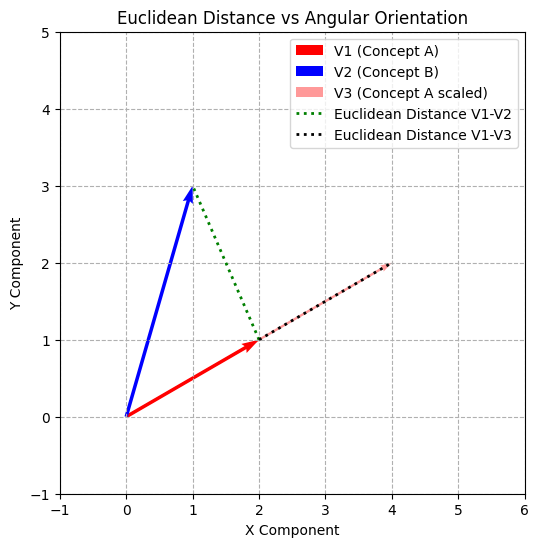

In [23]:
import numpy as np
import matplotlib.pyplot as plt

origin = np.array([0, 0])

# Dois vetores com ângulos distintos
v1 = np.array([2, 1])
v2 = np.array([1, 3])

# Um vetor longo, perfeitamente paralelo ao v1 (mesmo ângulo, magnitude maior)
v3 = np.array([4, 2])

plt.figure(figsize=(6, 6))
plt.quiver(*origin, v1[0], v1[1], color='r', angles='xy', scale_units='xy', scale=1, label='V1 (Concept A)')
plt.quiver(*origin, v2[0], v2[1], color='b', angles='xy', scale_units='xy', scale=1, label='V2 (Concept B)')
plt.quiver(*origin, v3[0], v3[1], color='r', angles='xy', scale_units='xy', scale=1, width=0.005, alpha=0.4, label='V3 (Concept A scaled)')

# Representando a distância L2 com linha pontilhada
plt.plot([v1[0], v2[0]], [v1[1], v2[1]], 'g:', linewidth=2, label='Euclidean Distance V1-V2')
plt.plot([v1[0], v3[0]], [v1[1], v3[1]], 'k:', linewidth=2, label='Euclidean Distance V1-V3')

plt.xlim(-1, 6)
plt.ylim(-1, 5)
plt.grid(True, linestyle='--')
plt.title('Euclidean Distance vs Angular Orientation')
plt.xlabel('X Component')
plt.ylabel('Y Component')
plt.legend()
plt.show()




### 3. Teoria formal

As equações atestadas no limite contínuo discriminam os componentes normalizados responsáveis por afastar ou atrair numericamente elementos no mapa matricial n-dimensional.

**Distância Euclidiana (Norma L2):** Projeta-se o valor de raízes unidas nas bases elementares retas no mapeamento multidimensional total, e baseia-se na raiz das soma dos quadrados: $$d_{euclid}(\mathbf{x}, \mathbf{y}) = \sqrt{\sum_{i=1}^{n} (x_i - y_i)^2}$$

**Similaridade de Cosseno:** Limita estritamente ao raio polar da normalização, subtraindo das grandezas e amplitudes colossais causadoras do sofrimento e punição nos cálculos gigantescos multidimensionais de modelos linguísticos de palavras cruzadas longas limitadas a espectros exatos ($-1, 1$): $$sim_{cos}(\mathbf{x}, \mathbf{y}) = \frac{\mathbf{x} \cdot \mathbf{y}}{||\mathbf{x}|| \cdot ||\mathbf{y}||}$$ A "Distância" dedutiva do cálculo espelha no formato da subtração linear contínua unitária: $d_{cos} = 1 - sim_{cos}$.

### 4. Algoritmos

A listagem desmembra os loops encarregados de normalizar os limites independentes de cada vetor singular e extrai o desvio paramétrico angular num produto unitário fixo sem sofrer do crescimento de escala algorítmico global.



ALGORITMO CalcularDistanciaDoCosseno
ENTRADA: Vetor X, Vetor Y de dimensões N
SAÍDA: Escalar flutuante (Distância restrita de 0 a 2)

ProdutoInterno = 0.0
SomaQuadrado_X = 0.0
SomaQuadrado_Y = 0.0

Para i de 0 até N-1 faça:
    ProdutoInterno += (X[i] * Y[i])
    SomaQuadrado_X += (X[i] * X[i])
    SomaQuadrado_Y += (Y[i] * Y[i])

Norma_X = RaizQuadrada(SomaQuadrado_X)
Norma_Y = RaizQuadrada(SomaQuadrado_Y)

Similaridade = ProdutoInterno / (Norma_X * Norma_Y)
Distancia = 1 - Similaridade

Retornar Distancia



O algoritmo acumula concomitantemente todos os fatores num loop único. Evita repassadas iterativas desgastantes para cada norma algébrica singular do espectro do modelo.

### 5. Implementação from scratch

Essa área encuba as mecânicas exatas da teoria das semelhanças vetoriais com puras execuções NumPy visando confirmar que o comportamento não flutua.



In [24]:
import numpy as np

def cosine_distance_scratch(x: np.ndarray, y: np.ndarray) -> float:
    """
    Evaluates angular cosine distance without relying on high-level APIs.

    Args:
        x (np.ndarray): Vector A.
        y (np.ndarray): Vector B.

    Returns:
        float: Computed angular distance scalar.
    """
    # Computação rigorosa de Produto Interno
    dot_product = np.dot(x, y)

    # Computação analítica do enquadramento L2 (norma) isolado
    norm_x = np.sqrt(np.sum(x**2))
    norm_y = np.sqrt(np.sum(y**2))

    sim = dot_product / (norm_x * norm_y)
    return float(1 - sim)

# Vetores paralelos: mesma direção, magnitudes diferentes -> distância angular = 0
vec_short = np.array([1.0, 0.0])
vec_long  = np.array([10.0, 0.0])

c_dist = cosine_distance_scratch(vec_short, vec_long)
print(f"Scratch Cosine Distance (Parallel Vectors): {c_dist:.5f}")
# Tolerância de pontos numéricos cravam no espectro zero de diferença real
assert np.isclose(c_dist, 0.0), "Parallel structures should present 0 angular distance."


Scratch Cosine Distance (Parallel Vectors): 0.00000




### 6. Implementação em PyTorch

A recriação a seguir adota a semântica moderna e unificada via tensores matriciais encapsulados no framework para garantir paralelismo maciço e retropropagação ativa dos limiares.



In [25]:
import torch
import torch.nn.functional as F

t_v1 = torch.tensor([1.0, 0.0], dtype=torch.float32)
t_v2 = torch.tensor([10.0, 0.0], dtype=torch.float32)

# F.cosine_similarity processa tensores na estrutura de pares de lote (Batch, Dim)
# Usando unsqueeze para contornar e simular este comportamento na avaliação crua
pt_sim = F.cosine_similarity(t_v1.unsqueeze(0), t_v2.unsqueeze(0))
pt_dist = 1 - pt_sim

print(f"PyTorch Cosine Distance: {pt_dist.item():.5f}")
assert torch.allclose(pt_dist, torch.tensor(0.0)), "Angular divergence algorithm error in API usage."


PyTorch Cosine Distance: 0.00000




O método isola a operação de divisão sob os bastidores preenchendo as arestas contra as incisões dos tensores faltantes no grafo global da rede funcional PyTorch.

### 7. Experimentos e análise

O teste compara as reações da "Magnitude Euclidiana" contra as penalidades aplicadas ao "Cossseno Angular" sob expansão linear na direção geométrica da flecha, o que ilustra perfeitamente onde cada uma perde as estribeiras.



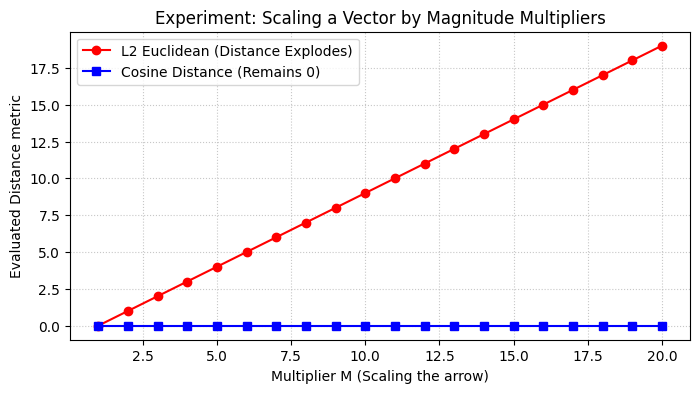

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# Crescimento exponencial ao decorrer da mesma base direcional idêntica
multipliers = np.linspace(1, 20, 20)
vec_base = np.array([1.0, 0.0])

euclid_distances = []
cosine_distances = []

for m in multipliers:
    vec_scaled = vec_base * m
    # Cálculos iterativos simulando medições perante a Base Pura original
    euclid_distances.append(np.linalg.norm(vec_base - vec_scaled))

    sim = np.dot(vec_base, vec_scaled) / (np.linalg.norm(vec_base) * np.linalg.norm(vec_scaled))
    cosine_distances.append(1 - sim)

plt.figure(figsize=(8, 4))
plt.plot(multipliers, euclid_distances, 'r-o', label='L2 Euclidean (Distance Explodes)')
plt.plot(multipliers, cosine_distances, 'b-s', label='Cosine Distance (Remains 0)')
plt.title('Experiment: Scaling a Vector by Magnitude Multipliers')
plt.xlabel('Multiplier M (Scaling the arrow)')
plt.ylabel('Evaluated Distance metric')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()




Constata-se indubitavelmente que, quando a projeção alarga o vetor, a medição formal L2 reage brutalmente penalizando o alongamento explodindo as métricas ao firmamento linear. Do outro lado, o medidor Cossseno dorme paralisado no chão zero do horizonte atestando similaridade plena de "Espaço Angular", confirmando e embasando o fato de que documentos textuais muito grandes seriam injustiçados perante os textinhos pequenos caso o mapeamento não os agrupassem pelo aspecto da similaridade diretiva em si ignorando a contagem de tokens nominais excedentes perante o volume latente cru da matriz.

### 8. Exercícios

As atividades fecham a percepção acerca das armadilhas da dimensão algorítmica ao mapear vetores em agrupamentos espaciais.

**Resolvidos:**

1. Geometricamente aponte a resposta de por que vetores retidos num enquadramento pequeno possuiriam distância L2 inócua mas relatórios Cossenos gigantescos e refratários em torno de sua avaliação total? _Solução:_ É possível quando situados no diâmetro e centro zero inicial do gráfico com inclinações espaciais brutalmente antagônicas. A amplitude exata do L2 mal arranha valores consideráveis devido as pontas limitadas, mas o cosseno angular deduz vetores inimigos dispostos perante direções espaciais inteiramente invertidas e espelhadas reportando anomalias imensas de proximidade relativas.
2. Num conjunto e mapeamento analítico contendo quatro dimensões idênticas e, avalie o traçado absoluto da métrica de cálculo L1 da linha de Manhattan perante sua magnitude explícita de desvio posicional exato e o resultado. _Solução:_ A soma crua retrai a avaliação bruta da amplitude das metragens de absoluto de distanciamento, resultando num L1 equivalente a avaliação dupla da distância (Valor Dois) de isolamentos puros de caminhos limítrofes entre si.
3. Considerando um mapa populacional e coordenadas latentes e posicionais cruas semânticas no plano do bairro limítrofe, se a predição deseja enjaular aglomerações e bairros baseados em posições territoriais fixadas absolutas (Clusterizações K-Means explícita de proximidade territorial), aplica-se qual método principal e avaliativo destas engrenagens para sanar as bacias limitantes do eixo referencial? _Solução:_ A Distância Euclidiana L2 atua sobre o comportamento real da posição e de cruzamento no espaço puro dimensional garantindo limites aceitáveis e perfeitamente agrupáveis limitantes semânticos angulares inúteis para problemas estritamente regionais.

**Desafios Abertos:**

1. Aferição da Divergência de Mapeamentos probabilísticos de Kullback-Leibler atua e projeta um papel atômico sob distribuições espaciais exatas da variância nas regressões limitadas por métricas espaciais não espaciais. Implante um cômputo da fórmula de divergência logarítmica KL manual perante a linguagem limpa numpy sobrepondo avaliações absolutas de arranjos bidimensionais.
2. Formule rigorosamente o diagrama algébrico relacional em base dimensional da fórmula limitante da Similaridade de Jaccard estritamente aplicável aos conceitos matemáticos estritamente esparsos e defina qual o cenário limitante de predição do aprendizado ao qual a mecânica se enquadra superando o arranjo limitante Cosseno.

---

# Parte 5: Grafos

### 1. Contextualização histórica e motivação

A presente etapa apresenta os fundamentos da malha matemática voltada às conexões causais imateriais, desprendidas da necessidade obrigatória dos arrays estáticos tabulares da álgebra convencional.

O tratamento dos problemas focados em topologia estrutural nasce indiretamente de enigmas modelados no século XVIII (As Sete Pontes de Königsberg), quando Leonard Euler traçou nós abstratos interligados no papel para demonstrar matematicamente a inviabilidade da travessia não redundante. Para a engenharia cibernética contemporânea da Inteligência Artificial nos moldes avançados do mundo de hoje em 2024-2025, os algoritmos e bases arquitetônicas demandam correlações implícitas e emaranhadas desvencilhadas de formatos textuais retilíneos. Redes Sociais, Mapas de rodovias e Detecção orgânica de fraudes interligadas demandam mapeamentos estritamente baseados nas chamadas árvores e estruturas complexas e heterogêneas dos grafos. A modernidade alavanca os mecanismos do _Graph RAG_ em conjunto a LLMs, que em vez de realizar recuperações vetoriais brutas estáticas nos arquivos indexados, navegam em entidades conexas mapeadas ativamente via grafos de conhecimento (_Knowledge Graphs_).

### 2. Intuição e visualização

A atual seção constrói um paralelo entre entidades e links atrelados aos conceitos, materializando em bolinhas e linhas uma abstração etérea computacional.

O Grafo baseia-se fundamentalmente num emparelhamento limpo de dois objetos atômicos e simples: os vértices soltos dispersos na prancheta que simbolizam Entidades, Contas bancárias de estelionatários, ou Indivíduos no espaço, e de Arestas flutuantes conectivas designando explicitamente e amarrando em elo uma correlação de comportamento ou compra ligando uma a outra na causalidade imaterial abstrata topológica. Se João (Nó 1) conhece Maria (Nó 2), uma Aresta estática crava a relação social amarrando ambos permanentemente na visão global e visual do mapa cibernético.



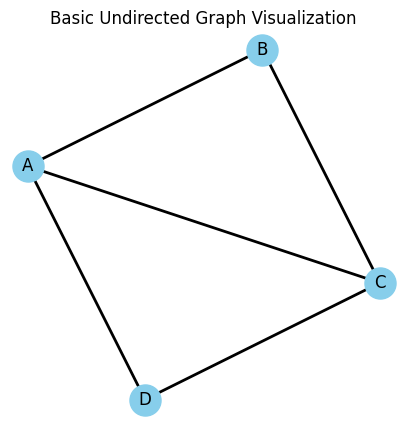

In [27]:
import matplotlib.pyplot as plt

# Entidades estáticas posicionais num plano solto da topologia geométrica fictícia
nodes = {'A': (1, 3), 'B': (3, 4), 'C': (4, 2), 'D': (2, 1)}

# Conexões amarradas (Edges) simuladas
edges = [('A', 'B'), ('A', 'C'), ('B', 'C'), ('C', 'D'), ('D', 'A')]

plt.figure(figsize=(5, 5))

# Renderizando as arestas como linhas da prancheta
for e in edges:
    pt1, pt2 = nodes[e[0]], nodes[e[1]]
    plt.plot([pt1[0], pt2[0]], [pt1[1], pt2[1]], 'k-', linewidth=2, zorder=1)

# Renderizando os nós (bolinhas centrais)
for name, coords in nodes.items():
    plt.scatter(*coords, s=500, color='skyblue', zorder=2)
    plt.text(coords[0], coords[1], name, fontsize=12, ha='center', va='center', zorder=3)

plt.title('Basic Undirected Graph Visualization')
plt.axis('off')
plt.show()




### 3. Teoria formal

O tópico estabelece a delimitação formal das nomenclaturas exigidas pela ciência matemática exata baseadas em conjuntos unificados das malhas de nós atômicos interconectados em teorias conjuntas bidimensionais soltas e direcionais explícitas.

Um grafo é definido impreterivelmente de forma axiomática pelo conjunto emparelhado de pares organizados num modelo abstrato fixado $G = (V, E)$, em que $V$ consolida num agrupamento exato e restrito de nós contidos na avaliação, e $E$ concentra o conjunto correlacional emparelhando exata das arestas contidas na modelagem matemática avaliativa entre nós isolados bidimensionais $[V, E]$. Arestas que possuem direções implícitas contidas em flechas definem Grafos Direcionais limitados perante a via da seta, impossibilitando regressos contrários. Representações em memória contêm abertamente a alocação de "Matriz de Adjacência" abrigando colossais $O(N \times N)$ de zeros cruzados entre todos os dados inúteis massivos do eixo denso espacial, assim como "Lista de Adjacência" contendo o mapeamento atômico das estruturas singulares poupadas por limites de interações explícitos isolados.

### 4. Algoritmos

A segmentação elucida a busca estruturada por conexões indiretas alocadas de modo esparso sobre uma árvore adjacente baseada num mecanismo que localiza se duas fronteiras são ligadas limitadas indiretamente nas matrizes numéricas soltas adjacentes.



ALGORITMO BuscaGrauAdjascenciaGrafo
ENTRADA: Lista_Adjascencia GRAFO, No ORIGEM, No DESTINO
SAÍDA: Verdadeiro ou Falso

FILA_VISITA = NovaFila()
NOS_VISITADOS = NovoConjuntoVazio()

FILA_VISITA.Adicionar(ORIGEM)
NOS_VISITADOS.Adicionar(ORIGEM)

Enquanto FILA_VISITA nao estiver vazia faça:
    NO_ATUAL = FILA_VISITA.RemoverPrimeiro()

    Se NO_ATUAL == DESTINO então:
        Retornar Verdadeiro

    Para cada VIZINHO em GRAFO[NO_ATUAL] faça:
        Se VIZINHO não em NOS_VISITADOS então:
            NOS_VISITADOS.Adicionar(VIZINHO)
            FILA_VISITA.Adicionar(VIZINHO)

Retornar Falso



O algoritmo descreve a busca lateral amarrada na estrutura de Listas enxutas e escassas. O programa alimenta listas e enjaula bolinhas marcadas evitando repassadas em ciclos mortos, alastrando e verificando adjacências diretas até aterrissar organicamente num limite final de validações dos nós ou engolir vazios.

### 5. Implementação from scratch

O código aninha e enjaula a malha numa infraestrutura alocada dinamicamente amparada em listas encadeadas das estruturas adjacentes primárias do dicionário limpo e nativo na programação Python limpa e alocada esparsamente.



In [28]:
class CustomGraph:
    """
    Representation of an undirected graph leveraging an adjacency list topology.
    Optimized for memory in sparse domains O(N + E).
    """
    def __init__(self):
        # Dicionário subjacente que engloba as malhas esparsas de conjuntos V E da teoria
        self.adj_list = {}

    def add_edge(self, node_u, node_v):
        """Injects a bidirectional unweighted connection."""
        if node_u not in self.adj_list:
            self.adj_list[node_u] = []
        if node_v not in self.adj_list:
            self.adj_list[node_v] = []

        self.adj_list[node_u].append(node_v)
        self.adj_list[node_v].append(node_u)

    def check_connection(self, u, v) -> bool:
        """Determines if a direct spatial connection links U and V."""
        if u not in self.adj_list:
            return False
        return v in self.adj_list[u]

# Validação do maquinário
g = CustomGraph()
g.add_edge("Alice", "Bob")
g.add_edge("Bob", "Charlie")

print(f"Scratch: Alice directly linked to Bob? {g.check_connection('Alice', 'Bob')}")
print(f"Scratch: Alice directly linked to Charlie? {g.check_connection('Alice', 'Charlie')}")

assert g.check_connection("Alice", "Bob") is True, "Logic failure in adjacency linkage."
assert g.check_connection("Alice", "Charlie") is False, "False positive in topology detection."


Scratch: Alice directly linked to Bob? True
Scratch: Alice directly linked to Charlie? False




### 6. Implementação em PyTorch

A recriação encampa matrizes bidimensionais densas nos blocos internos das estruturas PyTorch, forçando paralelismo pesado com o intuito das camadas operacionais matriciais absorverem os saltos vetoriais e cálculos imensos e exaustivos em blocos estáticos.



In [29]:
import torch

# Representação em arranjo de Matrizes Densas de Adjacência: N x N
# [Alice, Bob, Charlie]
# 1 = Existe Link; 0 = Vácuo Desconectado
adj_matrix = torch.tensor([
    [0.0, 1.0, 0.0], # Alice conectada somento ao Bob
    [1.0, 0.0, 1.0], # Bob conectado na Alice e no Charlie
    [0.0, 1.0, 0.0]  # Charlie conectado somente no Bob
], dtype=torch.float32)

def check_direct_link_pytorch(mat: torch.Tensor, i: int, j: int) -> bool:
    """Verifies edge connection via strict matrix index probing."""
    return mat[i, j].item() == 1.0

print(f"PyTorch Matrix: Alice (0) linked to Bob (1)? {check_direct_link_pytorch(adj_matrix, 0, 1)}")
print(f"PyTorch Matrix: Alice (0) linked to Charlie (2)? {check_direct_link_pytorch(adj_matrix, 0, 2)}")

assert check_direct_link_pytorch(adj_matrix, 0, 1) is True, "Matrix dense representation bug."


PyTorch Matrix: Alice (0) linked to Bob (1)? True
PyTorch Matrix: Alice (0) linked to Charlie (2)? False




Nota-se com extrema lucidez que a adoção da formatação de arranjo Matriz exige que todos os espaços do buraco negro latente fiquem contidos no tensor retido estaticamente do framework, engolindo parcelas dantescas de armazenamento GPU se a rede escalar absurdamente para bilhões das chaves não correlacionadas do arranjo latente.

### 7. Experimentos e análise

O laboratório afere exatamente os prejuízos infligidos e alocados nos limites da memória da máquina ao abrigar arranjos baseados no mapeamento em nuvem da Adjacência Matriz perante os mapeamentos enxutos isolados em Adjacências Lista, rastreando onde o cérebro eletrônico desfalece de letargia ineficiente.



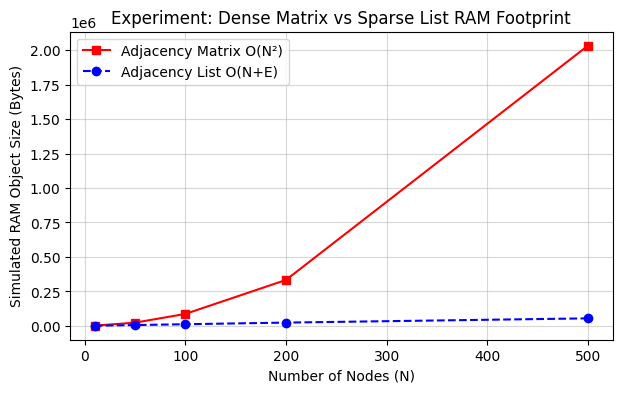

In [30]:
import sys
import matplotlib.pyplot as plt

num_nodes = [10, 50, 100, 200, 500]
mem_list = []
mem_matrix = []

for n in num_nodes:
    # Experimento A: Simulação do Peso da Memória da Matriz Densa O(N x N)
    dense_matrix = [[0] * n for _ in range(n)]
    mem_matrix.append(sys.getsizeof(dense_matrix) + sum(sys.getsizeof(row) for row in dense_matrix))

    # Experimento B: Simulação do Peso Esparso da Lista contendo meras 2 conexões espaciais por nó
    sparse_list = {i: [min(i + 1, n - 1), max(i - 1, 0)] for i in range(n)}
    mem_list.append(sys.getsizeof(sparse_list) + sum(sys.getsizeof(val) for val in sparse_list.values()))

plt.figure(figsize=(7, 4))
plt.plot(num_nodes, mem_matrix, 'r-s', label='Adjacency Matrix O(N²)')
plt.plot(num_nodes, mem_list, 'b--o', label='Adjacency List O(N+E)')
plt.title('Experiment: Dense Matrix vs Sparse List RAM Footprint')
plt.xlabel('Number of Nodes (N)')
plt.ylabel('Simulated RAM Object Size (Bytes)')
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()




Evidencia-se inegavelmente que a estrutura compacta matricial engatilha uma explosão da complexidade abismal parabólica ao acomodar zeros fúteis inoperantes que engasgam os limites da memória da máquina. A Lista Adjacente cresce serenamente colada numa planície linear pacata adaptativa focada estritamente e exclusivamente nos nós interconectados que detêm as verdades da malha orgânica alocada com destreza semântica útil para aplicações gigantescas do orbe web virtual.

### 8. Exercícios

Este aglomerado revalida conceitualmente o raciocínio exigido para distinguir a estrutura topológica orgânica frente às amarrações espaciais clássicas dos vetores isolados.

**Resolvidos:**

1. Descreva o motivo técnico pelo qual as Listas adjacentes detêm superioridade absoluta e massiva frente às Matrizes nos cenários onde os grafos enxergam uma vasta população mundial das Redes Sociais. _Solução:_ Matrizes geram e alocam O(NxN) registros e marcações estáticas mortas. Como a imensa porção global dos vizinhos orgânicos da rede mundial permanecem estritamente desconectados na realidade causal inter-humana, as Listas compactam esse lixo guardando apenas links vivos úteis.
2. Qual a limitação inegociável contida num grafo que opera num modelo "Acíclico" contínuo sem fluxos regressivos? _Solução:_ A malha algorítmica impossibilita integralmente e proíbe retornos diretos iterativos contínuos, de forma que avançar pelo bloco inviabiliza e isola o nó passado do caminho progressivo num ciclo irreversível de mão única trancada permanentemente.
3. Define o que personifica um construto de "Multigrafo" nas detecções complexas financeiras e como operam os laços emparelhados das suas arestas? _Solução:_ Diferem abertamente dos grafos restritivos pois retém arranjos paralelos duplos simultâneos. Uma conta envia remessas ilegais, e em conjunto deposita laços extras espaciais numa base idêntica da mesma filial criando duplicações exatas orgânicas simultâneas de relações heterogêneas dispares.

**Desafios Abertos:**

1. Monte os arranjos e pseudocódigos computacionais que viabilizem a leitura do PageRank atômico distribuindo percentuais e pesos iterativos avaliados numa malha bidirecional de grafos direcionados não lineares de citações em publicações exatas latentes estritas da internet.
2. Formule estruturalmente a representação do Grafo de Conhecimento RAG de forma semântica extraindo de um texto NLP as correlações latentes estruturais isoladas em tensores bidirecionais da relação Entidade -> Ação -> Entidade sem depender de prompts engessados dos LLMs gerativos estáticos restritos e herméticos do processamento latente.